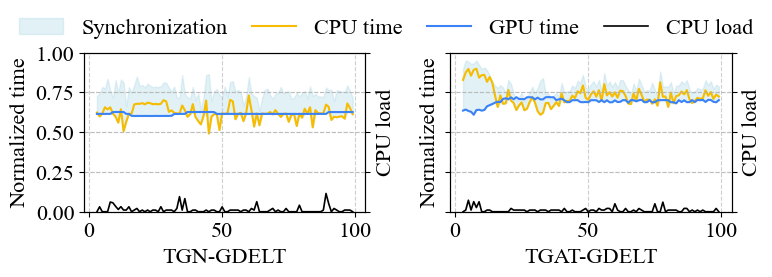

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 16
})

def load_panel_data(csv_path):
    df = pd.read_csv(csv_path)
    df = df.iloc[3:].reset_index(drop=True)
    x    = df["iter"].to_numpy()
    tC   = df["tC_ms"].to_numpy()
    tG   = df["tG_ms"].to_numpy()
    wall = df["wall_ms"].to_numpy()
    load = df["Lcurr"].to_numpy()
    return x, tC, tG, wall, load

def _set_axis_0to1_with_5ticks(ax):
    ticks = np.linspace(0, 1, 5)  # 0, 0.25, 0.5, 0.75, 1
    ax.set_ylim(0, 1.0)
    ax.set_yticks(ticks)
    ax.set_yticklabels([f"{t:.2f}" for t in ticks])

def plot_panel(ax, x, tC, tG, wall, load, ref,
               show_left_labels=True, show_right_labels=False):
    # 归一化
    tC_n, tG_n, wall_n = tC/ref, tG/ref, wall/ref
    lower = np.minimum(tC_n, tG_n)
    mask  = wall_n > lower

    # 阴影（同步开销区域）
    h_shade = ax.fill_between(
        x, lower, wall_n, where=mask, interpolate=True,
        color="lightblue", alpha=0.35, label="Synchronization Time (shaded)"
    )

    # 曲线
    h_cpu, = ax.plot(x, tC_n, color="#F5BC00", linewidth=1.5, label="CPU time")
    h_gpu, = ax.plot(x, tG_n, color="#3B82F6", linewidth=1.5, label="GPU time")

    ax.set_ylabel("Normalized time")
    _set_axis_0to1_with_5ticks(ax)

    # 右轴：CPU load
    ax2 = ax.twinx()
    h_load, = ax2.plot(x, load, color="black", linewidth=1.2, label="CPU load")
    
    ax2.set_ylabel("CPU load")
    _set_axis_0to1_with_5ticks(ax2)
    # 只保留刻度线，不要数字（根据需求控制）
    # 左轴：如果不显示数字，则保留刻度线但隐藏数字
    ax.tick_params(axis='y', which='both',
                   left=True, right=False,  # 左轴的刻度线只在左侧
                   labelleft=show_left_labels, labelright=False)

    # 右轴：刻度线在右侧；按需隐藏数字
    ax2.tick_params(axis='y', which='both',
                    left=False, right=True,
                    labelleft=False, labelright=show_right_labels)
    ax.grid(True, which='both', linestyle='--', alpha=0.6)
    ax2.grid(True, which='both', linestyle='--', alpha=0.6)
    
    return [h_shade, h_cpu, h_gpu, h_load], \
           ["Synchronization", "CPU time", "GPU time", "CPU load"]

# ================== 数据 ==================
left_csv = "het_log2.csv"
x_L, tC_L, tG_L, wall_L, load_L = load_panel_data(left_csv)

right_csv = "het_log.csv"
x_R, tC_R, tG_R, wall_R, load_R = load_panel_data(right_csv)

# ================== 绘图 ==================
fig, axes = plt.subplots(1, 2, figsize=(8, 2.7), sharex=False, sharey=False)
axes[0].set_xlabel("TGN-GDELT")
# 左边子图：左轴显示数字；右轴不显示数字（但保留刻度线）
hL, lL = plot_panel(axes[0], x_L, tC_L, tG_L, wall_L, load_L, ref=15,
                    show_left_labels=True, show_right_labels=False)

# 右边子图：左右轴都不显示数字（保留刻度线）
hR, lR = plot_panel(axes[1], x_R, tC_R, tG_R, wall_R, load_R, ref=30,
                    show_left_labels=False, show_right_labels=False)
axes[1].set_xlabel("TGAT-GDELT")
# 公共图例（用左图的句柄）
fig.legend(hL, lL, loc="lower center", ncol=4,
           frameon=False, bbox_to_anchor=(0.5, 0.86),columnspacing=1.1)

fig.tight_layout()
plt.savefig('exp6.pdf', bbox_inches='tight')
plt.show()
